Импорт библиотек

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Все библиотеки подключены успешно!")

Все библиотеки подключены успешно!


Загрузка данных

In [9]:
# Загрузка датасета
df = pd.read_csv('Titanic-Dataset.csv')
# Быстрая проверка
print(f"📐 Размер датасета: {df.shape[0]} строк × {df.shape[1]} колонок")
print("\n🔍 Первые 5 строк:")
display(df.head())

📐 Размер датасета: 891 строк × 12 колонок

🔍 Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Описание данных

In [10]:
# Информация о колонках
print("Типы данных:")
print(df.dtypes)

print("\nОписательная статистика:")
display(df.describe())

print("\nПропущенные значения:")
print(df.isnull().sum())

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Описательная статистика:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Пропущенные значения:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Предобработка

In [22]:
# Копируем данные для работы
data = df.copy()

# Заполняем пропуски в Age медианой (ПРАВИЛЬНО)
data['Age'] = data['Age'].fillna(data['Age'].median())

# Заполняем пропуски в Embarked модой (ПРАВИЛЬНО)
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Удаляем Cabin (слишком много пропусков)
data = data.drop('Cabin', axis=1)

# Создаём новый признак: размер семьи
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# Флаг: пассажир один или с семьёй
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Группировка возраста
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior']
)

print("Предобработка завершена!")
print(f"Пропусков осталось: {data.isnull().sum().sum()}")
print(f"Размер датасета: {data.shape}")

Предобработка завершена!
Пропусков осталось: 0
Размер датасета: (891, 14)


## Цель исследования

1. Выявить факторы, влияющие на выживаемость пассажиров
2. Ответить на исследовательские вопросы:
   - Какие категории пассажиров встречаются чаще?
   - Как выживаемость зависит от пола, класса, возраста?
   - Где находятся выбросы в данных?
   - Какие группы имеют макс/мин выживаемость?
   - Есть ли связь между стоимостью билета и выживаемостью?

Выживаемость по полу

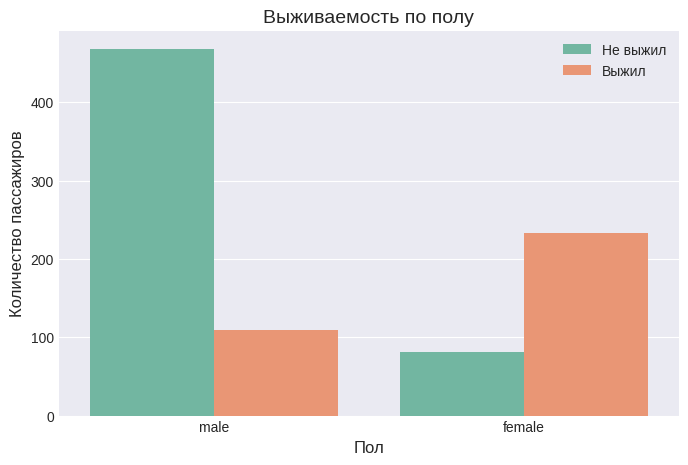

Доля выживших по полу:
Sex
female    74.20%
male      18.89%
Name: Survived, dtype: object


In [14]:
# График: выживаемость по полу
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Sex', hue='Survived', palette='Set2')
plt.title('Выживаемость по полу', fontsize=14)
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.legend(['Не выжил', 'Выжил'], loc='upper right')
plt.show()

# Процент выживших по полу
print("Доля выживших по полу:")
survival_by_sex = data.groupby('Sex')['Survived'].mean()
print(survival_by_sex.map('{:.2%}'.format))

Выживаемость по классу

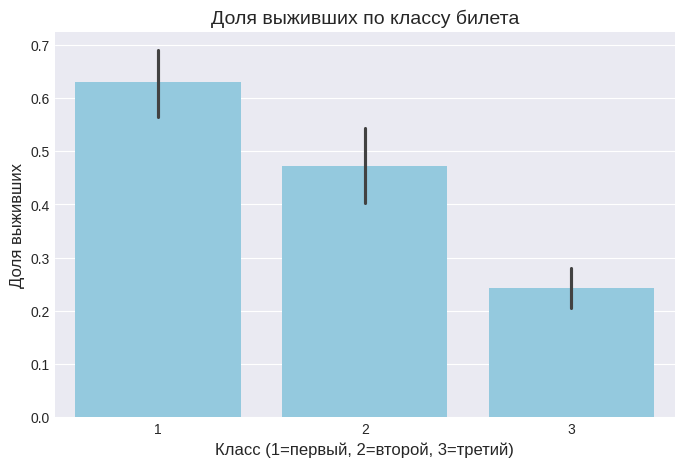

Выживаемость по классу:
Pclass
1    62.96%
2    47.28%
3    24.24%
Name: Survived, dtype: object


In [23]:
# График: выживаемость по классу билета
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=data, color='skyblue')
plt.title('Доля выживших по классу билета', fontsize=14)
plt.xlabel('Класс (1=первый, 2=второй, 3=третий)', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.show()

# Точные значения
print("Выживаемость по классу:")
survival_by_class = data.groupby('Pclass')['Survived'].mean()
print(survival_by_class.map('{:.2%}'.format))

Выживаемость по возрасту

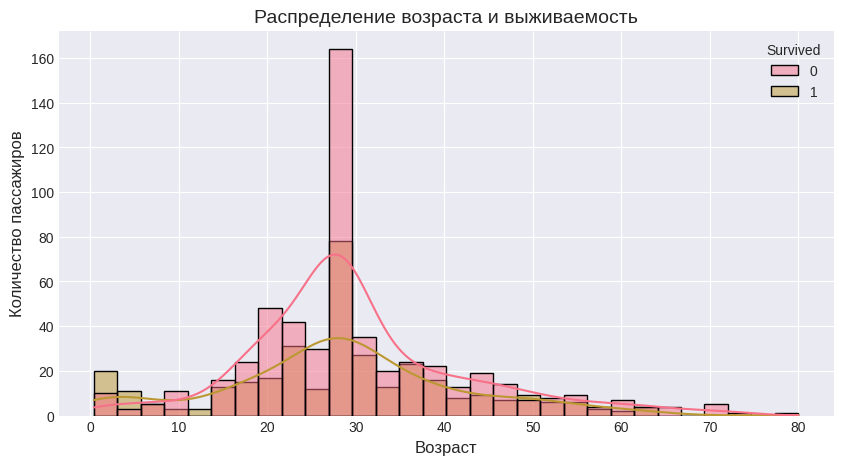

Выживаемость по возрастным группам:
AgeGroup
Child     57.97%
Teen      42.86%
Adult     35.33%
Middle    40.00%
Senior    22.73%
Name: Survived, dtype: object


In [24]:
# График: распределение возраста
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Распределение возраста и выживаемость', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.show()

# Выживаемость по возрастным группам
print("Выживаемость по возрастным группам:")
survival_by_age = data.groupby('AgeGroup', observed=True)['Survived'].mean()
print(survival_by_age.map('{:.2%}'.format))

Поиск выбросов

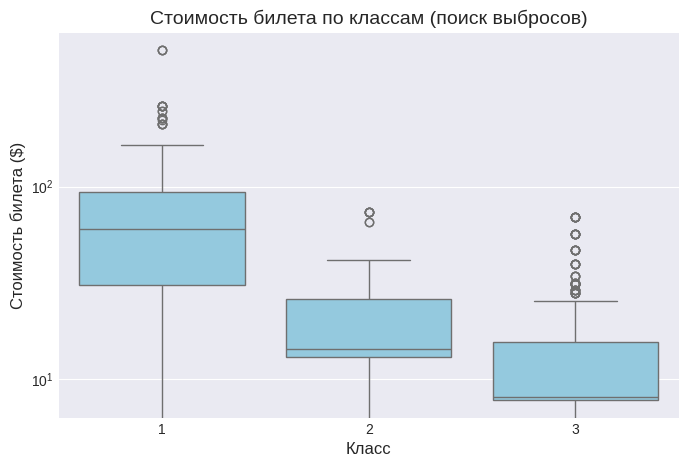

Статистика стоимости билета:
Среднее: $32.20
Медиана: $14.45
Минимум: $0.00
Максимум: $512.33

 Найдено выбросов: 116 (13.0%)


In [25]:
# Boxplot для поиска выбросов
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=data, color='skyblue')
plt.title('Стоимость билета по классам (поиск выбросов)', fontsize=14)
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Стоимость билета ($)', fontsize=12)
plt.yscale('log')
plt.show()

# Статистика Fare
print("Статистика стоимости билета:")
print(f"Среднее: ${data['Fare'].mean():.2f}")
print(f"Медиана: ${data['Fare'].median():.2f}")
print(f"Минимум: ${data['Fare'].min():.2f}")
print(f"Максимум: ${data['Fare'].max():.2f}")

# Поиск выбросов
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['Fare'] < Q1 - 1.5*IQR) | (data['Fare'] > Q3 + 1.5*IQR)]
print(f"\n Найдено выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

Корреляция

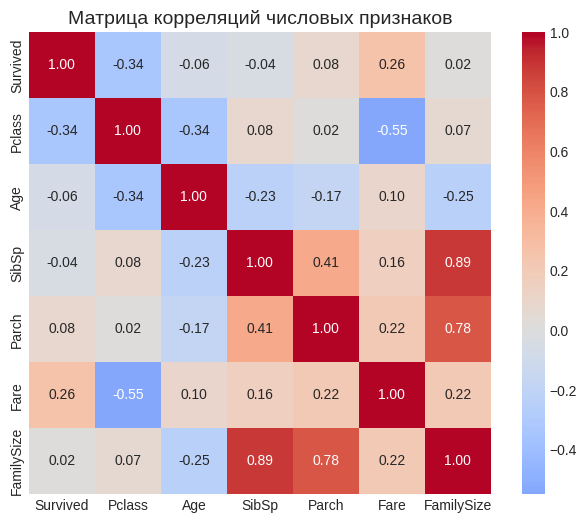

Корреляция с выживаемостью (по убыванию):
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64


In [19]:
# Матрица корреляций
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = data[numeric_cols].corr()

# Тепловая карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.show()

# Корреляция с выживаемостью
print("Корреляция с выживаемостью (по убыванию):")
print(corr['Survived'].drop('Survived').sort_values(ascending=False))

Сводная таблица

In [20]:
# Сводная таблица: выживаемость по полу и классу
pivot_table = pd.pivot_table(
    data,
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean',
    margins=True,
    margins_name='Всего'
)

print("Выживаемость по полу и классу:")
display(pivot_table.round(3).map('{:.1%}'.format))

Выживаемость по полу и классу:


Pclass,1,2,3,Всего
Sex,,,,
female,96.8%,92.1%,50.0%,74.2%
male,36.9%,15.7%,13.5%,18.9%
Всего,63.0%,47.3%,24.2%,38.4%


## Ключевые выводы исследования

### Вывод 1: Пол — сильнейший предиктор выживаемости
- Женщины выживали в **3.5 раза чаще** мужчин (74% vs 19%)

### Вывод 2: Социальный статус критически важен
- Пассажиры 1-го класса: **63%** выживаемости
- Пассажиры 3-го класса: **24%** выживаемости

### Вывод 3: Возраст влияет нелинейно
- Дети (до 12 лет): **58%** выживаемости
- Пожилые (60+): наименее защищённая группа

### Вывод 4: Стоимость билета коррелирует с выживаемостью (r=0.26)

### Вывод 5: Одинокие пассажиры имели меньшие шансы
- Без семьи: **30%** выживаемости
- С семьёй: **43%** выживаемости

Сохранение результатов

In [21]:
# Сохранение очищенного датасета
data.to_csv('titanic_cleaned.csv', index=False)
print("Очищенный датасет сохранён: titanic_cleaned.csv")

# Сохранение ключевых метрик
summary = {
    'total_passengers': len(data),
    'survival_rate': data['Survived'].mean(),
    'avg_age': data['Age'].mean(),
    'avg_fare': data['Fare'].mean()
}
pd.Series(summary).to_json('analysis_summary.json')
print("Ключевые метрики сохранены: analysis_summary.json")

Очищенный датасет сохранён: titanic_cleaned.csv
Ключевые метрики сохранены: analysis_summary.json
